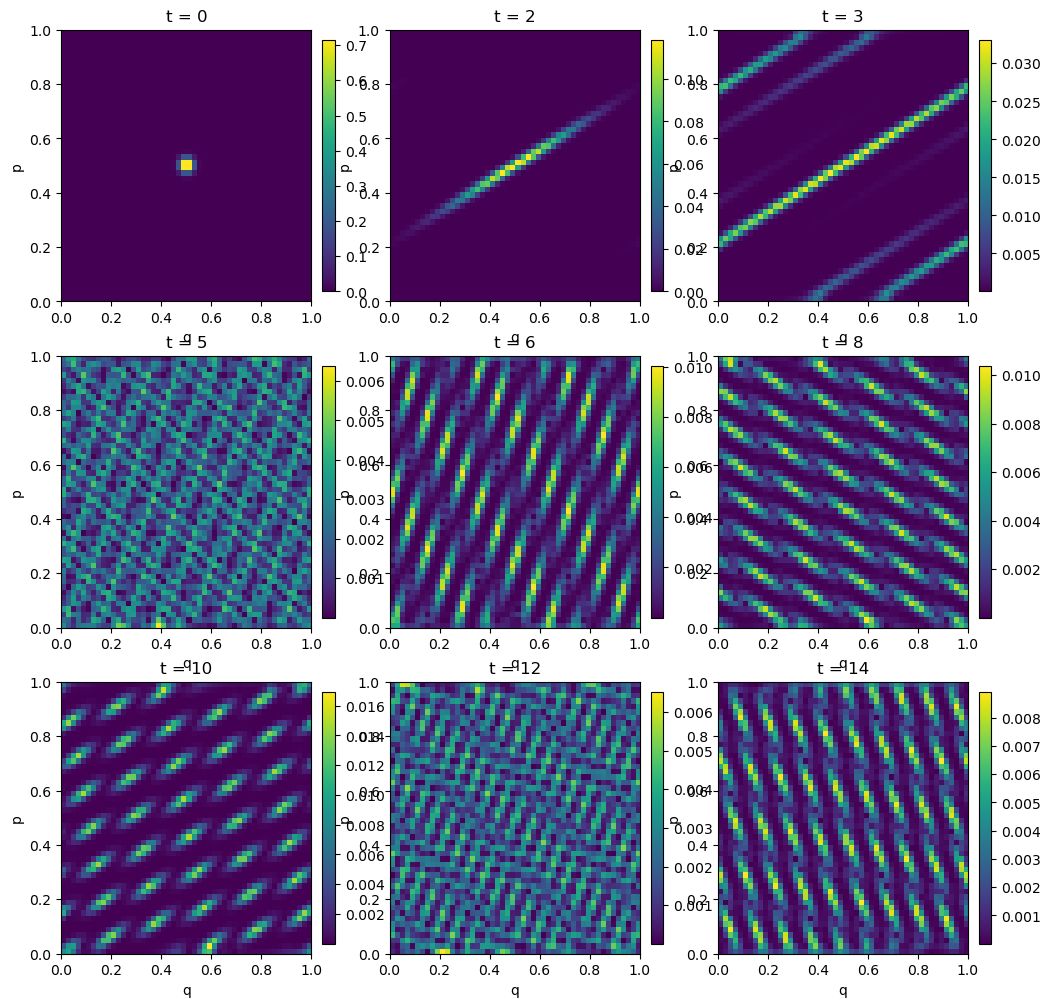

In [4]:
# Codes for obtaining the plot as in fig (2): Quantum Husimi Distribution at
# different time instances for initially localised coherent state unitarily evolved under the dy-
# namics of Arnold cat map.

import numpy as np
N = 512
hbar = 1 / (2 * np.pi * N)
q = np.arange(N) / N

q0 = 0.5        # position center
p0 = 0.5        # momentum center

sigma = np.sqrt(hbar)
def coherent_state(q, q0, p0, hbar):
    sigma = np.sqrt(hbar)
    psi = (1 / (np.pi * sigma**2))**0.25 \
          * np.exp(-(q - q0)**2 / (2 * sigma**2)) \
          * np.exp(1j * p0 * (q - q0) / hbar)
    return psi / np.linalg.norm(psi)
psi0 = coherent_state(q, q0, p0, hbar)

U = np.zeros((N, N), dtype=complex)
for m in range(N):
    for n in range(N):
        U[m, n] = (1 / np.sqrt(N)) * np.exp(
            2j * np.pi * (m*m - m*n + n*n) / N
        )
t_list = [0, 2,3, 5, 6, 8, 10,12,14]
psi_t_dict = {}
psi = psi0.copy()
psi_t_dict[0] = psi.copy()
t_max = max(t_list)
for t in range(1, t_max + 1):
    psi = U @ psi
    if t in t_list:
        psi_t_dict[t] = psi.copy()
def husimi_distribution(psi, q, q_grid, p_grid, hbar):
    Q = np.zeros((len(q_grid), len(p_grid)))
    
    for i, q0 in enumerate(q_grid):
        for j, p0 in enumerate(p_grid):
            phi = coherent_state(q, q0, p0, hbar)
            Q[i, j] = np.abs(np.vdot(phi, psi))**2
    return Q
n_grid = 50
q_grid = np.linspace(0, 1, n_grid)
p_grid = np.linspace(0, 1, n_grid)
husimi_dict = {}

for t in t_list:
    husimi_dict[t] = husimi_distribution(
        psi_t_dict[t], q, q_grid, p_grid, hbar
    )
import matplotlib.pyplot as plt
import math
N = len(t_list)
nrows = 3
ncols = math.ceil(N / nrows)
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
axes = axes.flatten()  # make indexing easy
for i, t in enumerate(t_list):
    im = axes[i].imshow(
        husimi_dict[t],
        extent=[0, 1, 0, 1],
        origin='lower',
        aspect='auto'
    )
    axes[i].set_title(f't = {t}')
    axes[i].set_xlabel('q')
    axes[i].set_ylabel('p')
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
for j in range(i+1, len(axes)):
    axes[j].axis('off')
# plt.tight_layout()
# plt.show()
# print(q)

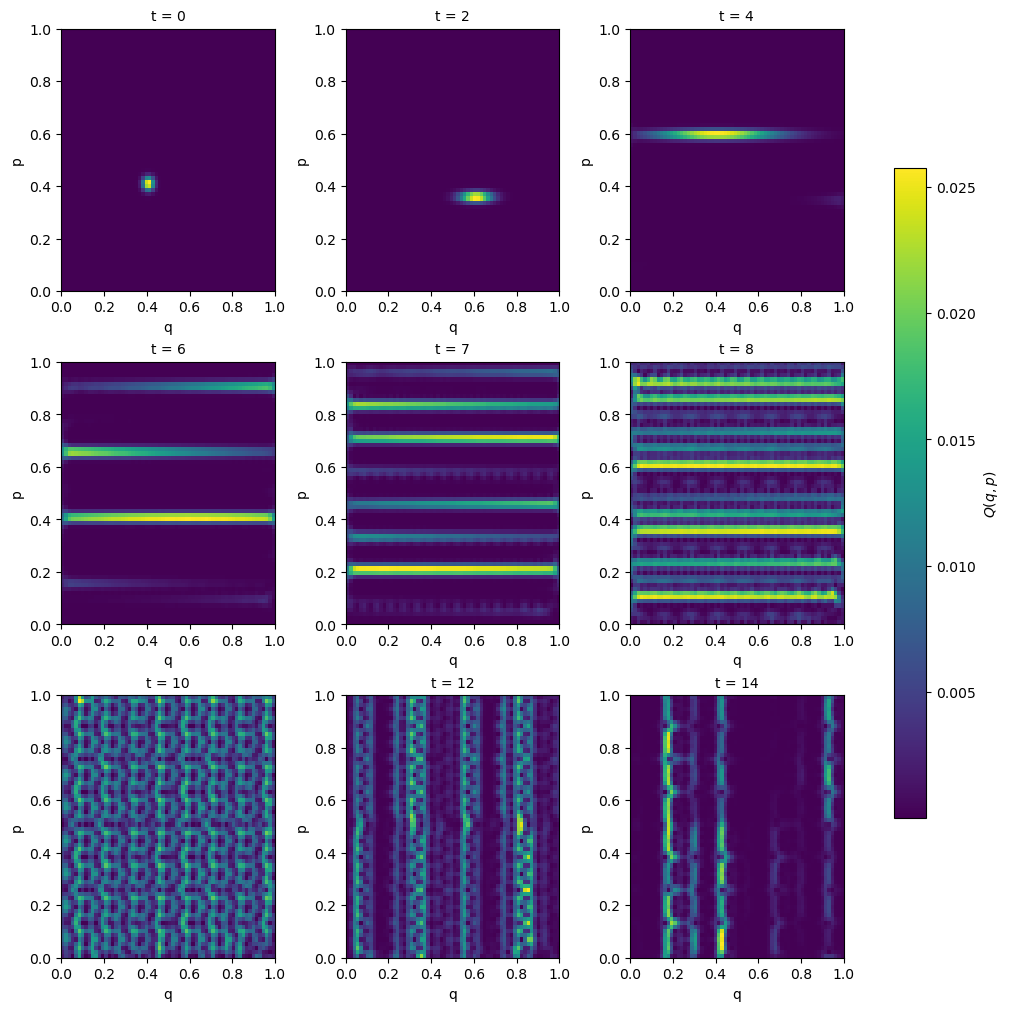

In [2]:
# Codes for obtaining the plot as in fig (3): Quantum Husimi Distribution at
# different time instances for initially localised coherent state unitarily evolved under the dy-
# namics of Baker map.

import numpy as np
import matplotlib.pyplot as plt
N = 512               
hbar = 1 / (2 * np.pi * N)
q = np.arange(N) / N
q0, p0 = 0.4, 0.4            
sigma = np.sqrt(hbar)
t_list = [0, 2, 4, 6, 7,8, 10,12,14]
grid_size = 64
q_grid = np.linspace(0, 1, grid_size, endpoint=False)
p_grid = np.linspace(0, 1, grid_size, endpoint=False)

def coherent_state_position(q, q0, p0, hbar):
    sigma = np.sqrt(hbar)
    psi = (1 / (np.pi * sigma**2))**0.25 \
        * np.exp(-(q - q0)**2 / (2 * sigma**2)) \
        * np.exp(1j * p0 * (q - q0) / hbar)
    return psi / np.linalg.norm(psi)

psi0 = coherent_state_position(q, q0, p0, hbar)

def fourier_matrix(N):
    n = np.arange(N)
    return np.exp(2j * np.pi * np.outer(n, n) / N) / np.sqrt(N)

def baker_unitary(N):
    assert N % 2 == 0

    F_N = fourier_matrix(N)
    F_N_dag = F_N.conj().T
    F_half = fourier_matrix(N // 2)

    block = np.zeros((N, N), dtype=complex)
    block[:N//2, :N//2] = F_half
    block[N//2:, N//2:] = F_half

    return F_N_dag @ block

U_baker = baker_unitary(N)

psi_t = {}
psi = psi0.copy()
psi_t[0] = psi.copy()

for t in range(1, max(t_list) + 1):
    psi = U_baker @ psi
    if t in t_list:
        psi_t[t] = psi.copy()


husimi = {}

for t in t_list:
    Q = np.zeros((grid_size, grid_size))
    for i, q0_ in enumerate(q_grid):
        for j, p0_ in enumerate(p_grid):
            coh = coherent_state(q, q0_, p0_, hbar)
            Q[i, j] = np.abs(np.vdot(coh, psi_t[t]))**2
    husimi[t] = Q

import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 3, figsize=(10, 10), constrained_layout=True)
axes = axes.flatten()

for ax, t in zip(axes, t_list):
    im = ax.imshow(
        husimi[t].T,
        origin='lower',
        extent=[0, 1, 0, 1],
        aspect='auto',
        cmap='viridis'
    )
    ax.set_title(f't = {t}', fontsize=10)
    ax.set_xlabel('q')
    ax.set_ylabel('p')
fig.colorbar(im, ax=axes.tolist(), shrink=0.7, label=r'$Q(q,p)$')

plt.show()

In [ ]:
# Codes for obtaining the plot as in fig (4):Real part of KD distribution for
# initially localised coherent state evolved under Arnold map.
import numpy as np
import matplotlib.pyplot as plt
N = 256 
hbar = 1 / (2 * np.pi * N)       
q = np.arange(N) / N            
q0 = 0.19
p0 = 0.9
t_list = [0,  2, 3, 4,  6,8,  10, 12, 14]
def coherent_state(q, q0, p0, hbar):
    sigma = np.sqrt(hbar)
    psi = (1 / (np.pi * sigma**2))**0.25 \
          * np.exp(-(q - q0)**2 / (2 * sigma**2)) \
          * np.exp(1j * p0 * (q - q0) / hbar)
    return psi / np.linalg.norm(psi)

psi0 = coherent_state(q, q0, p0, hbar)
U = np.zeros((N, N), dtype=complex)
for m in range(N):
    for n in range(N):
        U[m, n] = (1 / np.sqrt(N)) * np.exp(
            2j * np.pi * (m*m - m*n + n*n) / N
        )
psi_t_dict = {}
psi = psi0.copy()
psi_t_dict[0] = psi.copy()

t_max = max(t_list)

for t in range(1, t_max + 1):
    psi = U @ psi
    if t in t_list:
        psi_t_dict[t] = psi.copy()
def momentum_wavefunction(psi):
    return np.fft.fft(psi) / np.sqrt(len(psi))
def kd_distribution(psi):
    N = len(psi)
    psi_q = psi
    psi_p = momentum_wavefunction(psi)

    K = np.zeros((N, N), dtype=complex)
    for n in range(N):
        for m in range(N):
            phase = np.exp(2j * np.pi * n * m / N) / np.sqrt(N)
            K[n, m] = phase * psi_q[n] * np.conj(psi_p[m])
    return K

kd_dict = {t: kd_distribution(psi_t_dict[t]) for t in t_list}
def EoN_from_KD(K):
    """
    EoN = sum_{q,p} |Re K(q,p)| - 1
    """
    return np.sum(np.abs(np.real(K))) - 1

EoN_dict = {t: EoN_from_KD(kd_dict[t]) for t in t_list}

n_plots = len(t_list)
n_cols = 3
n_rows = int(np.ceil(n_plots / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()
for idx, t in enumerate(t_list):
    K = kd_dict[t]
    eon = EoN_dict[t]

    im = axes[idx].imshow(
        np.real(K),
        extent=[0, 1, 0, 1],
        origin='lower',
        cmap='seismic'
    )

    axes[idx].set_xlabel("q")
    axes[idx].set_ylabel("p")
    axes[idx].set_title(f"Re KD, t = {t}\nEoN = {eon:.3f}")
for ax in axes[len(t_list):]:
    ax.axis('off')
plt.tight_layout()
cbar = fig.colorbar(im, ax=axes, shrink=0.85)
cbar.set_label("Re K(q,p)")
plt.show()

In [ ]:
# Codes for obtaining the plot as in fig (7): Classical Phase space structure for
# Standard Map for various values of kicking parameters
import numpy as np
import matplotlib.pyplot as plt
def standard_map(q, p, K):
    P = (p + (K / (2*np.pi)) * np.sin(2 * np.pi * q)) % 1
    Q = (q + P) % 1
    return Q, P
Ks = [1, 2, 3, 3.5, 4, 4.5, 5, 6, 8]
n_iterations = 1000     
n_seeds = 80          
ncols = 3
nrows = int(np.ceil(len(Ks) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 10))
axes = axes.flatten()

for ax, K in zip(axes, Ks):

    seeds_q = np.linspace(0, 1, n_seeds)
    seeds_p = np.zeros(n_seeds)

    for i in range(n_seeds):
        Q, P = seeds_q[i], seeds_p[i]

        Q_pts = []
        P_pts = []

        for _ in range(n_iterations):
            Q, P = standard_map(Q, P, K)
            Q_pts.append(Q)
            P_pts.append(P)-
        ax.scatter(Q_pts, P_pts,
                   s=0.2,
                   c=np.arange(len(Q_pts)),   
                   cmap='ocean',
                   alpha=0.6)

    ax.set_title(f"K = {K}")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Q")
    ax.set_ylabel("P")
for i in range(len(Ks), len(axes)):
    fig.delaxes(axes[i])
plt.suptitle("Standard Map Phase Space ", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
#Codes for obtaining the plot as in fig (8):   Classical Information Decay for a state, evolved under the dynamics of Standard Map.
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

def standard_map(p, q, k):
    p_next = (p + (k / (2 * np.pi)) * np.sin(2 * np.pi * q)) % 1
    q_next = (q + p_next) % 1
    return p_next, q_next

def calculate_shannon_info(p, q, grid_size):
    ip = np.floor(p * grid_size).astype(int)
    iq = np.floor(q * grid_size).astype(int)

    ip = np.clip(ip, 0, grid_size - 1)
    iq = np.clip(iq, 0, grid_size - 1)

    indices = ip * grid_size + iq
    n_cells = grid_size**2

    counts = np.bincount(indices, minlength=n_cells)

    probs = counts[counts > 0] / len(p)

    return np.sum(probs * np.log(n_cells * probs))


def run_standard_sim(k, n_particles=10**6, grid_size=400, n_steps=15, n_histories=100):

    all_infos = np.zeros((n_histories, n_steps + 1))

    for h in range(n_histories):

        cp, cq = np.random.rand(), np.random.rand()

        p = (cp + (np.random.rand(n_particles) - 0.5) / grid_size) % 1
        q = (cq + (np.random.rand(n_particles) - 0.5) / grid_size) % 1

        all_infos[h, 0] = calculate_shannon_info(p, q, grid_size)

        for t in range(n_steps):

            p, q = standard_map(p, q, k)

            all_infos[h, t+1] = calculate_shannon_info(p, q, grid_size)

    return np.mean(all_infos, axis=0)
ks_vals = [20, 10, 5, 2, 3, 12]
grid_size = 400
n_steps = 15
fit_windows = {
    20: (1,4),
    10: (1,4),
    5: (1,4),
    2: (2,5),
    3: (2,5),
    12: (1,4)
}


print(f"{'k':<5} | {'Measured κ':<15} | {'Fit Window':<12}")
print("-" * 45)
plt.figure(figsize=(10,7))
time = np.arange(n_steps + 1)
for k in ks_vals:
    avg_info = run_standard_sim(
        k,
        n_particles=5*10**5,
        grid_size=grid_size,
        n_steps=n_steps,
        n_histories=60
    )
    t_start, t_end = fit_windows[k]
    t_fit = time[t_start:t_end]
    y_fit = avg_info[t_start:t_end]
    slope, intercept, r, p, stderr = linregress(t_fit, y_fit)
    measured_kappa = -slope
    print(f"{k:<5} | {measured_kappa:<15.3f} | ({t_start},{t_end})")
    plt.plot(time, avg_info, 'o-', label=f'k={k} (κ≈{measured_kappa:.2f})')
    plt.plot(t_fit, slope*t_fit + intercept, '--', linewidth=2)
plt.xlabel('Time (t)')
plt.ylabel('$I_{std}(t)$')
plt.title('Measuring Entropy Rate Slopes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# #Codes for obtaining the plot as in fig (8): Classical Information Decay for a
# state, evolved under the dynamics of Standard Map.
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
N = 1024
K_list = [2.5,3,3.5,4,4.5,5,6,10,12,15,20]
t_max = 10
num_realizations = 100
M = 40
fit_windows = {
    2.5: (1,4),
    3 : (1,4),
    3.5: (1,4),
    4: (1,4),
    4.5: (1,4),
    5: (0,4),
    6: (0,4),
    10: (0,3),
    12: (0,3),
    15: (0,3),
    20: (0,3),
}
hbar = 1 / (2 * np.pi * N)

p_vals = np.linspace(0, 1, M, endpoint=False)
q_vals = np.linspace(0, 1, M, endpoint=False)
pq_grid = np.array([(p, q) for p in p_vals for q in q_vals])

def coherent_state_pq(N, q0, p0):
    q_axis = np.arange(N) / N
    sigma = np.sqrt(hbar)
    psi = (1 / (np.pi * sigma**2))**0.25 \
          * np.exp(-(q_axis - q0)**2 / (2 * sigma**2)) \
          * np.exp(1j * p0 * (q_axis - q0) / (hbar))
    return psi / np.linalg.norm(psi)
def standard_map_unitary(N, K):
    n = np.arange(N)
    U_kick = np.diag(np.exp(-1j * K * N * np.cos(2 * np.pi * n / N) / (2 * np.pi)))
    p = np.arange(N)
    U_free_p = np.diag(np.exp(-1j * np.pi * p**2 / N))
    F = np.fft.fft(np.eye(N)) / np.sqrt(N)
    return F.conj().T @ U_free_p @ F @ U_kick
def get_oe(psi, pq_grid, N):
    overlaps = []
    for p,q in pq_grid:
        phi = coherent_state_pq(N,q,p)
        overlaps.append(np.abs(np.vdot(phi,psi))**2)

    Q = np.array(overlaps)
    Q /= np.sum(Q)
    return -np.sum(Q[Q>1e-15]*np.log(Q[Q>1e-15]))
plt.figure(figsize=(10,6))

print(f"{'K':<5} | {'OE Slope (λ_meas)':<18} | {'Classical λ (ln K/2)':<18}")
print("-"*55)
for K in K_list:
    U = standard_map_unitary(N,K)
    all_oe = np.zeros((num_realizations,t_max+1))

    for r in range(num_realizations):
        q0,p0 = np.random.rand(),np.random.rand()
        psi = coherent_state_pq(N,q0,p0)
        for t in range(t_max+1):
            all_oe[r,t] = get_oe(psi,pq_grid,N)
            psi = U @ psi
    avg_oe = np.mean(all_oe,axis=0)
    t_vals = np.arange(t_max+1)

    t_start, t_end = fit_windows[K]
    t_fit = t_vals[t_start:t_end]
    y_fit = avg_oe[t_start:t_end]
    slope,intercept,r_val,p_val,std_err = linregress(t_fit,y_fit)
    lambda_cl = np.log(K/2) if K>2 else 0
    print(f"{K:<5} | {slope:<18.4f} | {lambda_cl:<18.4f}")
    plt.plot(t_vals,avg_oe,'o-',label=f"K={K}, slope={slope:.2f},λ_th = {lambda_cl:.2f}")
    plt.plot(t_fit,slope*t_fit+intercept,'--',linewidth=2)

plt.xlabel("Time (steps)")
plt.ylabel("Average Observational Entropy")
plt.title("Growth of OE vs Time: Comparison with Lyapunov Exponent")

plt.legend()
plt.grid(True,linestyle='--',alpha=0.7)

plt.show()

In [ ]:
# Codes for obtaining the plot as in fig (9): Growth of Observational Entropy
# for the initially localised coherent state, unitarily evolved under the Hamiltonian dynamics of
# Standard Map for a system of dimension N = 1024.
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
N = 1024
K_list = [2.5,3,3.5,4,4.5,5,6,10,12,15,20]
t_max = 10
num_realizations = 100
M = 40
fit_windows = {
    2.5: (1,4),
    3 : (1,4),
    3.5: (1,4),
    4: (1,4),
    4.5: (1,4),
    5: (0,4),
    6: (0,4),
    10: (0,3),
    12: (0,3),
    15: (0,3),
    20: (0,3),
}
hbar = 1 / (2 * np.pi * N)

p_vals = np.linspace(0, 1, M, endpoint=False)
q_vals = np.linspace(0, 1, M, endpoint=False)
pq_grid = np.array([(p, q) for p in p_vals for q in q_vals])

def coherent_state_pq(N, q0, p0):
    q_axis = np.arange(N) / N
    sigma = np.sqrt(hbar)
    psi = (1 / (np.pi * sigma**2))**0.25 \
          * np.exp(-(q_axis - q0)**2 / (2 * sigma**2)) \
          * np.exp(1j * p0 * (q_axis - q0) / (hbar))
    return psi / np.linalg.norm(psi)
def standard_map_unitary(N, K):
    n = np.arange(N)
    U_kick = np.diag(np.exp(-1j * K * N * np.cos(2 * np.pi * n / N) / (2 * np.pi)))
    p = np.arange(N)
    U_free_p = np.diag(np.exp(-1j * np.pi * p**2 / N))
    F = np.fft.fft(np.eye(N)) / np.sqrt(N)
    return F.conj().T @ U_free_p @ F @ U_kick
def get_oe(psi, pq_grid, N):
    overlaps = []
    for p,q in pq_grid:
        phi = coherent_state_pq(N,q,p)
        overlaps.append(np.abs(np.vdot(phi,psi))**2)

    Q = np.array(overlaps)
    Q /= np.sum(Q)
    return -np.sum(Q[Q>1e-15]*np.log(Q[Q>1e-15]))
plt.figure(figsize=(10,6))

print(f"{'K':<5} | {'OE Slope (λ_meas)':<18} | {'Classical λ (ln K/2)':<18}")
print("-"*55)
for K in K_list:
    U = standard_map_unitary(N,K)
    all_oe = np.zeros((num_realizations,t_max+1))

    for r in range(num_realizations):
        q0,p0 = np.random.rand(),np.random.rand()
        psi = coherent_state_pq(N,q0,p0)
        for t in range(t_max+1):
            all_oe[r,t] = get_oe(psi,pq_grid,N)
            psi = U @ psi
    avg_oe = np.mean(all_oe,axis=0)
    t_vals = np.arange(t_max+1)

    t_start, t_end = fit_windows[K]
    t_fit = t_vals[t_start:t_end]
    y_fit = avg_oe[t_start:t_end]
    slope,intercept,r_val,p_val,std_err = linregress(t_fit,y_fit)
    lambda_cl = np.log(K/2) if K>2 else 0
    print(f"{K:<5} | {slope:<18.4f} | {lambda_cl:<18.4f}")
    plt.plot(t_vals,avg_oe,'o-',label=f"K={K}, slope={slope:.2f},λ_th = {lambda_cl:.2f}")
    plt.plot(t_fit,slope*t_fit+intercept,'--',linewidth=2)

plt.xlabel("Time (steps)")
plt.ylabel("Average Observational Entropy")
plt.title("Growth of OE vs Time: Comparison with Lyapunov Exponent")

plt.legend()
plt.grid(True,linestyle='--',alpha=0.7)

plt.show()

In [ ]:
#Codes for obtaining the plot as in fig (10): Averaged Extent of negativity versus time for standard map for varying $k$, averaged over coherent states intially localised at 100 different $(p_0,q_0)$.
import numpy as np
import matplotlib.pyplot as plt
N = 512
K_list = [0.1,0.4,0.8,1, 2, 4,5, 6, 8]
t_max = 15
n_avg = 100   
def coherent_state(N, q0, p0):
    hbar = 1 / (2 * np.pi * N)
    q = np.arange(N) / N
    sigma = np.sqrt(hbar)

    psi = (1 / (np.pi * sigma**2))**0.25 \
          * np.exp(-(q - q0)**2 / (2 * sigma**2)) \
          * np.exp(1j * p0 * (q - q0) / hbar)

    return psi / np.linalg.norm(psi)

def standard_map_unitary(N, K):
    hbar = 1 / (2 * np.pi * N)
    q = np.arange(N) / N
    p = np.arange(N) / N

    U_kick = np.diag(
        np.exp(-1j * K * np.cos(q) / (2 * np.pi * hbar))
    )
    U_free_p = np.diag(
        np.exp(-1j * (p)**2 / (2 * hbar))
    )
    F = np.exp(2j * np.pi * np.outer(np.arange(N), np.arange(N)) / N) / np.sqrt(N)
    U_free = F.conj().T @ U_free_p @ F
    return U_free @ U_kick
def momentum_wavefunction(psi):
    return np.fft.fft(psi) / np.sqrt(len(psi))

def kd_distribution(psi):
    N = len(psi)
    psi_q = psi
    psi_p = momentum_wavefunction(psi)

    K = np.zeros((N, N), dtype=complex)
    for n in range(N):
        for m in range(N):
            phase = np.exp(2j * np.pi * n * m / N) / np.sqrt(N)
            K[n, m] = phase * psi_q[n] * np.conj(psi_p[m])
    return K
def EoN_from_KD(KD):
    return np.sum(np.abs(np.real(KD))) - 1
plt.figure(figsize=(7,5))
for K_val in K_list:
    U = standard_map_unitary(N, K_val)

    EoN_avg = np.zeros(t_max + 1)

    for _ in range(n_avg):
        q0 = np.random.uniform(0, 1)
        p0 = np.random.uniform(0, 1)

        psi = coherent_state(N, q0, p0)

        for t in range(t_max + 1):
            if t > 0:
                psi = U @ psi

            KD = kd_distribution(psi)
            EoN_avg[t] += EoN_from_KD(KD)
    EoN_avg /= n_avg

    plt.plot(range(t_max + 1), EoN_avg, marker='o', label=f"K = {K_val}")

plt.xlabel("Time (kicks)")
plt.ylabel("Average Extent of KD Negativity (EoN)")
plt.title(f"Average EoN vs Time for Standard Map (N = {N})")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#  Codes for obtaining the plot as in fig (11):  Classical Phase space structure for Kicked Harper Map for various values of kicking parameters in the
# momentum evolution term (with kicking parameter in the position evolution term fixed. 
import numpy as np
import matplotlib.pyplot as plt
def harper_map(q, p, K, L):
    P = (p + K * np.sin(2*np.pi*q)) % 1
    Q = (q - L * np.sin(2*np.pi*P)) % 1
    return Q, P
Ks = [0.2,0.25,0.4,0.5,0.75,1,1.5,2,3,4]
L = 0.25
n_iterations = 2000
n_seeds = 40

fig, axes = plt.subplots(1,len(Ks),figsize=(25,4),sharey=True)

for ax, K in zip(axes, Ks):
    for _ in range(n_seeds):
        q = np.random.rand()
        p = np.random.rand()
        Q_pts = []
        P_pts = []
        for _ in range(n_iterations):

            q,p = harper_map(q,p,K,L)

            Q_pts.append(q)
            P_pts.append(p)

        ax.plot(Q_pts,P_pts,',',markersize=0.7)
    ax.set_title(f"K = {K}")
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)
    ax.set_xlabel("Q")
axes[0].set_ylabel("P")
plt.suptitle("Classical Harper Map Phase Space",fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
 #Codes for obtaining the plot as in fig (12): : Classical Information Decay for a state, evolved under the dynamics of Kicked Harper Map. 
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
def harper_map_step(p, q, K, L):

    p_next = (p + K * np.sin(2*np.pi*q)) % 1
    q_next = (q - L * np.sin(2*np.pi*p_next)) % 1
    return p_next, q_next
def calculate_shannon_info(p, q, grid_size):

    ip = np.floor(p * grid_size).astype(int)
    iq = np.floor(q * grid_size).astype(int)

    ip = np.clip(ip,0,grid_size-1)
    iq = np.clip(iq,0,grid_size-1)
    indices = ip*grid_size + iq
    n_cells = grid_size**2
    counts = np.bincount(indices,minlength=n_cells)
    probs = counts[counts>0] / len(p)
    return np.sum(probs*np.log(n_cells*probs))
def run_classical_harper_sim(K, L,
                             n_particles=2*10**5,
                             grid_size=200,
                             n_steps=15):

    p = np.random.uniform(0.49,0.51,n_particles)
    q = np.random.uniform(0.49,0.51,n_particles)
    infos = []
    for t in range(n_steps):
        infos.append(calculate_shannon_info(p,q,grid_size))
        p,q = harper_map_step(p,q,K,L)
    return np.array(infos)
K_list = [0.2,0.25,0.4,0.5,0.75,1,2,3,4]
L = 0.25
grid_size = 200
n_steps = 15
fit_windows = {
0.2:(1,6),
0.25:(1,6),
0.4:(0,3),
0.5:(0,3),
0.75:(4,7),
1:(2,6),
2:(1,4),
3:(0,3),
4:(0,3),
}
plt.figure(figsize=(8,6))

print(f"{'K':<6} | {'Measured κ':<15} | {'Theory λ':<15}")
print("-"*50)

for K in K_list:

    avg_info = run_classical_harper_sim(K,L)
    time = np.arange(len(avg_info))

    t_start,t_end = fit_windows[K]

    res = linregress(time[t_start:t_end],
                     avg_info[t_start:t_end])

    kappa = -res.slope
    lambda_th = np.log(np.pi**2 * K * L)
    lambda_th = max(0,lambda_th)

    print(f"{K:<6} | {kappa:<15.4f} | {lambda_th:<15.4f}")
    line, = plt.plot(time, avg_info, 'o-', markersize=3,
                     label=f"K={K}, κ={kappa:.2f}, λ={lambda_th:.2f}")

    plt.plot(time[t_start:t_end],
             res.slope*time[t_start:t_end] + res.intercept,
             '--', color=line.get_color())


plt.xlabel("Time")
plt.ylabel("Information $I(t)$")
plt.title("Classical Information Decay (with κ and λ)")
plt.legend(ncol=2, fontsize='small')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
#  Codes for obtaining the plot as in fig (13): Growth of Observational Entropy for the initially localised coherent state, unitarily evolved under the
# Hamiltonian dynamics of Kicked Harper Map for a system of dimension N = 1024
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
N = 1024
K_list = [0.2,0.25,0.4,0.5,0.75,1,1.5,2,3,4]
t_max = 10
num_realizations = 100
M = 40
fit_windows = {
    0.2: (1,4),
    0.25 : (1,4),
    0.4: (1,4),
    0.5: (1,4),
    0.75: (1,4),
    1: (0,4),
    1.5: (0,4),
    2: (0,3),
    3: (0,3),
    4: (0,3)
}
hbar = 1 / (2 * np.pi * N)
p_vals = np.linspace(0, 1, M, endpoint=False)
q_vals = np.linspace(0, 1, M, endpoint=False)
pq_grid = np.array([(p, q) for p in p_vals for q in q_vals])
def coherent_state_pq(N, q0, p0):
    q_axis = np.arange(N) / N
    sigma = np.sqrt(hbar)
    psi = (1 / (np.pi * sigma**2))**0.25 \
          * np.exp(-(q_axis - q0)**2 / (2 * sigma**2)) \
          * np.exp(1j * p0 * (q_axis - q0) / (hbar))
    return psi / np.linalg.norm(psi)
def standard_map_unitary(N, K):
    n = np.arange(N)
    U_p = np.diag(np.exp(-1j * (K/(2 * np.pi)) *  np.cos(2 * np.pi * n / N) / hbar))

    n_ = np.arange(N)
    U_q = np.diag(np.exp(-1j *(0.25/(2 * np.pi)) *np.cos(2 * np.pi * n_ / N) / hbar))
    F = np.fft.fft(np.eye(N)) / np.sqrt(N)
    return F.conj().T @ U_p @ F @ U_q
def get_oe(psi, pq_grid, N):
    overlaps = []
    for p,q in pq_grid:
        phi = coherent_state_pq(N,q,p)
        overlaps.append(np.abs(np.vdot(phi,psi))**2)

    Q = np.array(overlaps)
    Q /= np.sum(Q)

    return -np.sum(Q[Q>1e-15]*np.log(Q[Q>1e-15]))
plt.figure(figsize=(10,6))
print(f"{'K':<5} | {'OE Slope (λ_meas)':<18} | {'Classical λ (ln K/2)':<18}")
print("-"*55)
for K in K_list:
    U = standard_map_unitary(N,K)

    all_oe = np.zeros((num_realizations,t_max+1))

    for r in range(num_realizations):
        q0,p0 = np.random.rand(),np.random.rand()
        psi = coherent_state_pq(N,q0,p0)
        for t in range(t_max+1):

            all_oe[r,t] = get_oe(psi,pq_grid,N)
            psi = U @ psi
    avg_oe = np.mean(all_oe,axis=0)
    t_vals = np.arange(t_max+1)
    t_start, t_end = fit_windows[K]
    t_fit = t_vals[t_start:t_end]
    y_fit = avg_oe[t_start:t_end]
    slope,intercept,r_val,p_val,std_err = linregress(t_fit,y_fit)
    lambda_cl = np.log(np.pi**2 * 0.25*K) 
    print(f"{K:<5} | {slope:<18.4f} | {lambda_cl:<18.4f}")
    plt.plot(t_vals,avg_oe,'o-',label=f"K={K}, slope={slope:.2f},λ_th = {lambda_cl:.2f}")
    plt.plot(t_fit,slope*t_fit+intercept,'--',linewidth=2)

plt.xlabel("Time (steps)")
plt.ylabel("Average Observational Entropy")
plt.title("Growth of OE vs Time: Comparison with Lyapunov Exponent")
plt.legend()
plt.grid(True,linestyle='--',alpha=0.7)

plt.show()

In [ ]:
# Codes for obtaining the plot as in fig (14): Classical Phase space structure for Sawtooth Potential Map for various values of kicking parameters. 
import numpy as np
import matplotlib.pyplot as plt
def sawtooth_map(q, p, K):
    p_next = (p + K * q) % 1
    q_next = (q + p_next) % 1
    return q_next, p_next
K_values = [0.5, 2,5,10]   
n_steps = 800
grid_size = 20                   

q_lin = np.linspace(0, 1, grid_size)
p_lin = np.linspace(0, 1, grid_size)
q0, p0 = np.meshgrid(q_lin, p_lin)
q0 = q0.flatten()
p0 = p0.flatten()
fig, axes = plt.subplots(2,2, figsize=(10, 10))

for idx, K in enumerate(K_values):
    ax = axes[idx // 2, idx % 2]

    for i in range(len(q0)):
        q = q0[i]
        p = p0[i]

        qs = []
        ps = []

        for _ in range(n_steps):
            q, p = sawtooth_map(q, p, K)
            qs.append(q)
            ps.append(p)

        ax.scatter(qs, ps, s=0.3, alpha=0.6)
    ax.set_title(f"K = {K}")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("q")
    ax.set_ylabel("p")
plt.suptitle("Sawtooth Map Phase Space for Different K", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Codes for obtaining the plot as in fig (15):  Classical Information Decay for a state, evolved under the dynamics of Kicked Harper Map.
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
def standard_map(p, q, k):
    p_next = (p + k*q) % 1
    q_next = (q + p_next) % 1
    return p_next, q_next

def calculate_shannon_info(p, q, grid_size):

    ip = np.floor(p * grid_size).astype(int)
    iq = np.floor(q * grid_size).astype(int)

    ip = np.clip(ip, 0, grid_size - 1)
    iq = np.clip(iq, 0, grid_size - 1)

    indices = ip * grid_size + iq
    n_cells = grid_size**2

    counts = np.bincount(indices, minlength=n_cells)
    probs = counts[counts > 0] / len(p)

    return np.sum(probs * np.log(n_cells * probs))

def lyapunov_approx(k):
    return np.log((2+k + np.sqrt(k**2 +4)) / 2)
def run_standard_sim(k, n_particles=3*10**5, grid_size=400, n_steps=15, n_histories=40):

    all_infos = np.zeros((n_histories, n_steps + 1))

    for h in range(n_histories):

        cp, cq = np.random.rand(), np.random.rand()

        p = (cp + (np.random.rand(n_particles) - 0.5) / grid_size) % 1
        q = (cq + (np.random.rand(n_particles) - 0.5) / grid_size) % 1

        all_infos[h, 0] = calculate_shannon_info(p, q, grid_size)

        for t in range(n_steps):
            p, q = standard_map(p, q, k)
            all_infos[h, t+1] = calculate_shannon_info(p, q, grid_size)

    return np.mean(all_infos, axis=0)
ks_vals = sorted([1, 2, 4, 5, 6, 8, 10, 12, 15, 18, 20])

grid_size = 400
n_steps = 15
time = np.arange(n_steps + 1)
fit_windows = {
    1: (3,7),
    2: (2,5),
    4: (1,5),
    5: (1,5),
    6: (1,5),
    8: (1,5),
    10: (1,4),
    12: (1,4),
    15: (1,4),
    18: (1,4),
    20: (1,4),
}
kappa_list = []
lambda_list = []
print(f"{'k':<5} | {'κ (measured)':<15} | {'λ (approx)':<15}")
print("-" * 50)
plt.figure(figsize=(10,7))
for k in ks_vals:
    avg_info = run_standard_sim(k, grid_size=grid_size, n_steps=n_steps)
    t_start, t_end = fit_windows[k]
    t_fit = time[t_start:t_end]
    y_fit = avg_info[t_start:t_end]
    slope, intercept, *_ = linregress(t_fit, y_fit)
    kappa = -slope
    lam = lyapunov_approx(k)
    kappa_list.append(kappa)
    lambda_list.append(lam)
    print(f"{k:<5} | {kappa:<15.3f} | {lam:<15.3f}")
    plt.plot(time, avg_info, 'o-',
             label=f'k={k} (κ={kappa:.2f}, λ≈{lam:.2f})')

    plt.plot(t_fit, slope*t_fit + intercept, '--', linewidth=2)

plt.xlabel('Time (t)')
plt.ylabel('$I_{std}(t)$')
plt.title('Information Decay vs Time (Sawtooth Map)')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.figure(figsize=(6,6))
plt.scatter(lambda_list, kappa_list)
x = np.linspace(min(lambda_list), max(lambda_list), 100)
plt.plot(x, x, 'r--', label='κ = λ')

plt.xlabel('Lyapunov Exponent λ')
plt.ylabel('Entropy Growth Rate κ')
plt.title('κ vs λ (Standard Map)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Codes for obtaining the plot as in fig (16):  OE growth for the initially localised coherent state, unitarily evolved under the Hamiltonian for sawtooth
# map for system dimension N = 2048.
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
N = 2048
K_list = [1,2,4,5,6,8,10,12,15,18,20]
t_max = 10
num_realizations = 50
M = 50

hbar = 1 / (2 * np.pi * N)
fit_windows = {
    1: (1,5),
    2: (1,5),
    4: (0,3),
    5: (0,4),
    6: (0,4),
    8: (0,3),
    10: (0,3),
    12: (0,3),
    15: (0,3),
    18: (0,3),
    20: (0,3),
}
p_vals = np.linspace(0, 1, M, endpoint=False)
q_vals = np.linspace(0, 1, M, endpoint=False)
pq_grid = np.array([(p, q) for p in p_vals for q in q_vals])

def coherent_state_pq(N, q0, p0):
    q_axis = np.arange(N) / N
    sigma = np.sqrt(hbar)

    psi = (1 / (np.pi * sigma**2))**0.25 \
          * np.exp(-(q_axis - q0)**2 / (2 * sigma**2)) \
          * np.exp(1j * p0 * (q_axis - q0) / hbar)
    return psi / np.linalg.norm(psi)
coherent_states = np.array([coherent_state_pq(N,q,p) for p,q in pq_grid])
def sawtooth_unitary(N, K):
    n = np.arange(N)
    U_kick = np.diag(np.exp(-1j * np.pi * K * n**2 / N))
    p = np.arange(N)
    U_free_p = np.diag(np.exp(-1j * np.pi * p**2 / N))
    F = np.fft.fft(np.eye(N)) / np.sqrt(N)
    return F.conj().T @ U_free_p @ F @ U_kick
def get_oe_fast(psi):
    overlaps = np.abs(coherent_states @ psi)**2
    overlaps /= np.sum(overlaps)
    return -np.sum(overlaps[overlaps > 1e-15] * np.log(overlaps[overlaps > 1e-15]))
def lambda_sawtooth(K):
    val = (2+K + np.sqrt(K**2 + 4*K))/2
    return np.log(val)
plt.figure(figsize=(10,6))

print(f"{'K':<5} | {'OE slope':<12} | {'λ_theory':<12}")
print("-"*40)

for K in K_list:

    U = sawtooth_unitary(N,K)

    all_oe = np.zeros((num_realizations,t_max+1))

    for r in range(num_realizations):

        q0,p0 = np.random.rand(),np.random.rand()
        psi = coherent_state_pq(N,q0,p0)

        for t in range(t_max+1):
            all_oe[r,t] = get_oe_fast(psi)
            psi = U @ psi

    avg_oe = np.mean(all_oe,axis=0)
    t_vals = np.arange(t_max+1)
    t_start, t_end = fit_windows[K]
    t_fit = t_vals[t_start:t_end]
    y_fit = avg_oe[t_start:t_end]

    slope, intercept, *_ = linregress(t_fit,y_fit)

    lambda_th = lambda_sawtooth(K)

    print(f"{K:<5} | {slope:<12.4f} | {lambda_th:<12.4f}")

    plt.plot(t_vals,avg_oe,'o-',label=f"K={K}, slope={slope:.2f}, λ={lambda_th:.2f}")
    plt.plot(t_fit, slope*t_fit + intercept, '--', linewidth=2)

plt.xlabel("Time")
plt.ylabel("Observational Entropy")
plt.title("OE Growth vs Time (Sawtooth Map)")

plt.legend(fontsize=8)
plt.grid(True,linestyle='--',alpha=0.6)
plt.tight_layout()
plt.show()